# Architecture

In [1]:
import einops as eps
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from dataset import DexYCB
from utils import mano

/home/renkaiwen/.conda/envs/sl_vit/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Fix shapedirs bug of MANO


In [2]:
dataset_train = DexYCB("s0", "train")
dataset_test = DexYCB("s0", "test")

In [6]:
dataloader = torch.utils.data.DataLoader(dataset_train, batch_size=4, shuffle=True)

In [3]:
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:,None,None] + mean[:,None,None]
    return img.permute(1,2,0)

In [7]:
from tqdm import tqdm

data_iter = iter(dataloader)
for _ in tqdm(range(33), ncols=50):
    data_item = next(data_iter)

100%|█████████████| 33/33 [00:03<00:00,  8.48it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.9604645e-08..0.99714935].


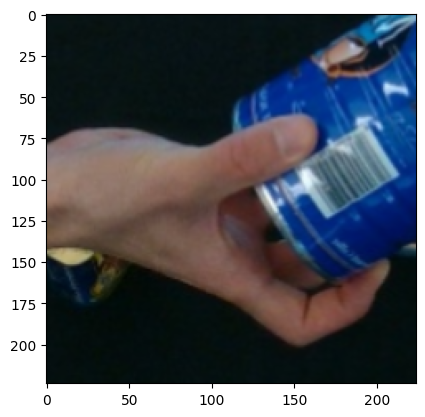

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

bx = 2

plt.clf()
image = data_item['image'][bx]
plt.imshow(unnormalize(image))
plt.show()

In [36]:
cv2.imwrite("origin.png", unnormalize(image).numpy()[:,:,[2,1,0]] * 255)

True

In [12]:
pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))

In [21]:
faces = mano.face['right']
verts_gt = output_gt.vertices[0].numpy()
mesh_gt = Poly3DCollection(verts_gt[faces], color='r', alpha=0.2, edgecolor='k')

In [29]:
def save_as_obj(verts, faces, filename):
    """
    将顶点和面信息保存为 .obj 文件
    
    参数:
        verts: 顶点列表 [(x1, y1, z1), (x2, y2, z2), ...]
        faces: 面列表 [[v1, v2, v3], [v4, v5, v6], ...]
        filename: 保存的 .obj 文件名
    """
    with open(filename, 'w') as f:
        # 写入顶点信息
        for vert in verts:
            f.write(f"v {vert[0]+1} {vert[1]+1} {vert[2]+1}\n")

        # 写入面信息
        for face in faces:
            face_str = " ".join(map(str, [v + 1 for v in face]))  # .obj 的索引从1开始
            f.write(f"f {face_str}\n")

In [30]:
save_as_obj(verts_gt, faces, "tmp.obj")

# Epoch-loss